Cleaning things up and writing more code with hopefully better thoughts

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from scipy.optimize import minimize_scalar
import matplotlib.cm as cm
import itertools
from itertools import combinations
from joblib import Parallel, delayed
import pickle
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import root_scalar
from scipy.sparse.linalg import eigsh
from scipy.sparse import csr_matrix, lil_matrix
from collections import defaultdict
from scipy.sparse.linalg import expm_multiply
from scipy.linalg import svd
from scipy.optimize import curve_fit
from scipy.optimize import brentq
from scipy.linalg import logm, sqrtm, expm
from qutip import *
import scipy.sparse as sp
from scipy.sparse import kron, eye, csr_matrix
from scipy.sparse.linalg import expm_multiply
import matplotlib.pyplot as plt
from functools import reduce
from math import comb
from scipy.linalg import logm, sqrtm, expm
from collections import defaultdict

In [23]:
# ----------------------------------------------------------------------
# 1. Define operators and Hamiltonian
# ----------------------------------------------------------------------

def cavity_annihilation(d):
    """Bosonic annihilation operator (truncated)."""
    data = np.sqrt(np.arange(1, d))
    return sp.diags(data, 1, format='csr')

def kron_all(ops):
    """Kronecker product over list of sparse ops."""
    return reduce(lambda a, b: kron(a, b, format='csr'), ops)

def embed_spin_op(op, i, L):
    """Embed 2x2 operator op at site i (0-based) in spin chain of length L."""
    I2 = csr_matrix(np.eye(2))
    ops = [I2]*L
    ops[i] = op
    return kron_all(ops)

def haar_random_couplings(L, strength=0.05, seed=None):
    """
    Generate a random Hermitian matrix J_{ij} with Haar-like distribution.
    J = U D U† where U is Haar unitary, D is real symmetric with scale 'strength'.
    """
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(L, L)) + 1j * rng.normal(size=(L, L))
    # Hermitian part
    H_rand = (X + X.conj().T) / 2.0
    # Normalize Frobenius norm and scale
    H_rand /= np.sqrt(np.mean(np.abs(H_rand)**2))
    return strength * H_rand

def build_H_cavity_exciton_band(L, N_cav, omega_c, omega_e_list, g, coupling_strength, hbar=1.0):
    """
    Build cavity-exciton Hamiltonian with GUE random couplings.
    
    H = ħω_c a†a 
        + Σ_i ω_e[i] b_i† b_i 
        + Σ_{i<j} (J[i,j] b_i† b_j + J[j,i] b_j† b_i)  [GUE couplings]
        + g Σ_i (a† b_i + a b_i†)                      [Cavity coupling]
    
    Where J is a Hermitian matrix from GUE: J[j,i] = J[i,j]*
    """
    assert len(omega_e_list) == L
    d_cav = N_cav + 1
    
    # Cavity operators
    a  = cavity_annihilation(d_cav)
    ad = a.conj().T
    n_c = ad @ a
    I_c = eye(d_cav, format='csr')
    
    # Exciton operators (two-level systems)
    b  = csr_matrix(np.array([[0, 1], [0, 0]], dtype=complex))
    bd = b.conj().T
    n  = bd @ b
    I_spin = eye(2**L, format='csr')
    
    # --- Build exciton Hamiltonian ---
    H_exciton = csr_matrix((2**L, 2**L), dtype=complex)
    
    # On-site energies: Σ_i ω_e[i] b_i† b_i
    for i, w_i in enumerate(omega_e_list):
        H_exciton += w_i * embed_spin_op(n, i, L)
    
    # Random couplings: Σ_{i<j} (J[i,j] b_i† b_j + J[j,i] b_j† b_i)
    J = haar_random_couplings(L, strength=coupling_strength, seed=42)
    
    # Verify J is Hermitian (optional, for debugging)
    assert np.allclose(J, J.conj().T), "J must be Hermitian!"
    
    for i in range(L):
        for j in range(i+1, L):
            # b_i† b_j creates excitation at i, destroys at j
            bij = embed_spin_op(bd, i, L) @ embed_spin_op(b, j, L)
            # b_j† b_i is the Hermitian conjugate
            bji = embed_spin_op(bd, j, L) @ embed_spin_op(b, i, L)
            
            # Add J[i,j] b_i† b_j + J[j,i] b_j† b_i
            # Since J is Hermitian: J[j,i] = J[i,j]*
            H_exciton += J[i, j] * bij + J[j, i] * bji
    
    # Embed exciton Hamiltonian in full space
    H_total_exciton = kron(I_c, H_exciton)
    
    # --- Cavity Hamiltonian ---
    H_cav = (hbar * omega_c) * kron(n_c, I_spin)
    
    # --- Cavity-exciton coupling: g Σ_i (a† b_i + a b_i†) ---
    H_coup = csr_matrix((d_cav * 2**L, d_cav * 2**L), dtype=complex)
    for i in range(L):
        bi  = embed_spin_op(b,  i, L)
        bdi = embed_spin_op(bd, i, L)
        H_coup += kron(ad, bi, format='csr') + kron(a, bdi, format='csr')
    
    # --- Full Hamiltonian ---
    H = H_cav + H_total_exciton + g * H_coup
    
    # Verify Hermiticity (optional, but recommended for debugging)
    # H_dense = H.toarray()
    # assert np.allclose(H_dense, H_dense.conj().T), "H must be Hermitian!"
    
    return H

    # Verified this function...it makes sense

# def build_H_exciton_band(L, omega_e_list, coupling_strength, hbar=1.0):
#     """
#     Build cavity-exciton Hamiltonian with GUE random couplings.
    
#     H =  Σ_i ω_e[i] b_i† b_i 
#         + Σ_{i<j} (J[i,j] b_i† b_j + J[j,i] b_j† b_i)  [GUE couplings]
    
#     Where J is a Hermitian matrix from GUE: J[j,i] = J[i,j]*
#     """
#     assert len(omega_e_list) == L

    
#     # Exciton operators (two-level systems)
#     b  = csr_matrix(np.array([[0, 1], [0, 0]], dtype=complex))
#     bd = b.conj().T
#     n  = bd @ b
#     I_spin = eye(2**L, format='csr')
    
#     # --- Build exciton Hamiltonian ---
#     H_exciton = csr_matrix((2**L, 2**L), dtype=complex)
    
#     # On-site energies: Σ_i ω_e[i] b_i† b_i
#     # for i, w_i in enumerate(omega_e_list):
#     #     H_exciton += w_i * embed_spin_op(n, i, L)
    
#     # Random couplings: Σ_{i<j} (J[i,j] b_i† b_j + J[j,i] b_j† b_i)
#     J = haar_random_couplings(L, strength=coupling_strength, seed=42)
    
#     # Verify J is Hermitian (optional, for debugging)
#     assert np.allclose(J, J.conj().T), "J must be Hermitian!"
    
#     for i in range(L):
#         for j in range(i+1, L):
#             # b_i† b_j creates excitation at i, destroys at j
#             bij = embed_spin_op(bd, i, L) @ embed_spin_op(b, j, L)
#             # b_j† b_i is the Hermitian conjugate
#             bji = embed_spin_op(bd, j, L) @ embed_spin_op(b, i, L)
            
#             # Add J[i,j] b_i† b_j + J[j,i] b_j† b_i
#             # Since J is Hermitian: J[j,i] = J[i,j]*
#             H_exciton += J[i, j] * bij + J[j, i] * bji
    
#     return H_exciton

def build_H_exciton_band(L, basis, scale=1.0, seed=None):
    """
    Create a Gaussian Unitary Ensemble (GUE) Hamiltonian in the bosonic basis.

    Parameters
    ----------
    L : int
        Number of lattice sites.
    basis : int
        Basis of the Hilbert space
    scale : float
        Overall energy scale (sets the standard deviation of matrix elements).
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    H : np.ndarray
        Hermitian random matrix (GUE) of shape (dim, dim).
    """
    rng = np.random.default_rng(seed)
    dim = len(basis)

    # Generate a random complex matrix with independent Gaussian entries
    A = rng.normal(0, 1, (dim, dim)) + 1j * rng.normal(0, 1, (dim, dim))
    
    # Symmetrize to make it Hermitian (GUE condition)
    H = (A + A.conj().T) / 2.0

    # Normalize to desired scale (optional: ensure variance = scale^2 / dim)
    H *= scale / np.sqrt(dim)

    return H

# ----------------------------------------------------------------------
# 2. Build initial state |φ> = |cav> ⊗ |excitons>
# ----------------------------------------------------------------------

def initial_state_general(L, N_cav, n_cav_init=0, excited_sites=None):
    """
    Build initial state with specified cavity photon number and exciton configuration.
    
    Parameters:
    -----------
    L : int
        Number of exciton sites
    N_cav : int
        Maximum cavity photon number (truncation)
    n_cav_init : int, optional
        Number of photons in cavity initially (default: 0)
    excited_sites : list of int or None, optional
        Indices of exciton sites to excite (0-based).
        If None or empty list, all excitons are in ground state (default: None)
    
    Returns:
    --------
    vec : array
        Initial state vector |n_cav> ⊗ |spin configuration>
    
    Examples:
    ---------
    # Cavity with 2 photons, all excitons in ground state
    psi0 = initial_state_general(L, N_cav, n_cav_init=2)
    
    # Empty cavity, excitons at sites 0 and 1 excited
    psi0 = initial_state_general(L, N_cav, n_cav_init=0, excited_sites=[0, 1])
    
    # 1 photon in cavity, exciton at site 5 excited
    psi0 = initial_state_general(L, N_cav, n_cav_init=1, excited_sites=[5])
    
    # Both cavity and excitons excited
    psi0 = initial_state_general(L, N_cav, n_cav_init=2, excited_sites=[3, 7])
    """
    d_cav = N_cav + 1
    d_spin = 2**L
    
    # Check cavity photon number is valid
    if n_cav_init < 0 or n_cav_init > N_cav:
        raise ValueError(f"n_cav_init={n_cav_init} must be in range [0, {N_cav}]")
    
    # Build spin configuration
    if excited_sites is None:
        excited_sites = []
    
    spin_idx = 0
    for site in excited_sites:
        if site < 0 or site >= L:
            raise ValueError(f"Site {site} out of range [0, {L-1}]")
        spin_idx += 2**(L - 1 - site)
    
    # Build state vector
    vec = np.zeros(d_cav * d_spin, dtype=complex)
    idx = n_cav_init * d_spin + spin_idx
    vec[idx] = 1.0
    
    return vec

def initial_state_exciton(L, excited_sites=None):
    """
    Build initial state with specified cavity photon number and exciton configuration.
    
    Parameters:
    -----------
    L : int
        Number of exciton sites

    excited_sites : list of int or None, optional
        Indices of exciton sites to excite (0-based).
        If None or empty list, all excitons are in ground state (default: None)
    
    Returns:
    --------
    vec : array
        Initial state vector |n_cav> ⊗ |spin configuration>
    
    Examples:
    ---------
    
    # Excitons at sites 0 and 1 excited
    psi0 = initial_state_general(L, N_cav, n_cav_init=0, excited_sites=[0, 1])
    
    """
    d_spin = 2**L
    
    # Build spin configuration
    if excited_sites is None:
        excited_sites = []
    
    spin_idx = 0
    for site in excited_sites:
        if site < 0 or site >= L:
            raise ValueError(f"Site {site} out of range [0, {L-1}]")
        spin_idx += 2**(L - 1 - site)
    
    # Build state vector
    vec = np.zeros(d_spin, dtype=complex)
    vec[spin_idx] = 1.0
    
    return vec

# ----------------------------------------------------------------------
# 3. Compute survival amplitude A(t) and probability P(t)
# ----------------------------------------------------------------------

def survival_probability(H, psi0, times):
    # Diagonalize
    evals, evecs = np.linalg.eigh(H.toarray())
    c = evecs.conj().T @ psi0              # c_μ = ⟨ψ_μ|φ⟩
    w = np.abs(c)**2                       # |⟨ψ_μ|φ⟩|²
    # Survival amplitude: A(t) = Σ_μ w_μ e^{-iE_μ t}
    A_t = np.exp(-1j * np.outer(times, evals)) @ w
    P_t = np.abs(A_t)**2
    return P_t, A_t, evals, w

def thermal_expectation_Hamiltonian(beta, evals):
    
    e_min = np.min(beta * evals)        # Shift energies to avoid overflow: numerical trick
    weights = np.exp(-(beta * evals - e_min))  # shifted exponent
    Z = np.sum(weights)
    thermal_E = np.sum(evals * weights) / Z
    return thermal_E

def find_beta_with_neg_temps(H, psi0, bracket=(-500, 500), plot=False):
    """Finds beta ∈ (−∞, ∞) such that thermal energy = ⟨ψ0|H|ψ0⟩."""
    E = np.vdot(psi0, H @ psi0).real
    evals, _ = np.linalg.eigh(H)

    def f(beta):
        return thermal_expectation_Hamiltonian(beta, evals) - E

    f_lo = f(bracket[0])
    f_hi = f(bracket[1])

    if np.sign(f_lo) == np.sign(f_hi):
        if plot:
            import matplotlib.pyplot as plt
            beta_vals = np.linspace(bracket[0], bracket[1], 500)
            thermal_vals = [thermal_expectation_Hamiltonian(b, evals) for b in beta_vals]
            plt.plot(beta_vals, thermal_vals, label="⟨H⟩_thermal(β)")
            plt.axhline(E, color='r', linestyle='--', label="E_init")
            plt.xlabel("β")
            plt.ylabel("Energy")
            plt.legend()
            plt.title("No root found: energy outside thermal range")
            plt.show()
        raise RuntimeError("No root in bracket: energy outside accessible thermal range.")

    beta_star = brentq(f, *bracket, xtol=1e-10)
    print(f"beta_star = {beta_star}")
    return beta_star, E 

def reduced_density_matrix_general(rho, basis, keep_sites, L):
    """
    Compute reduced density matrix by tracing out all sites except keep_sites.
    
    Parameters:
    -----------
    rho : array (2^L, 2^L)
        Full density matrix
    basis : array
        Computational basis indices [0, 1, 2, ..., 2^L - 1]
    keep_sites : list of int
        Sites to keep (0-indexed from LEFT)
    L : int
        Total number of sites
        
    Returns:
    --------
    rho_red : array (2^k, 2^k)
        Reduced density matrix where k = len(keep_sites)
    """
    dim_red = 2 ** len(keep_sites)
    rho_red = np.zeros((dim_red, dim_red), dtype=complex)
    
    # Precompute index mapping
    index_map = {}
    for idx in basis:
        # Extract bits for keep_sites (accounting for LEFT-to-RIGHT encoding)
        keep_bits = [(idx >> (L - 1 - s)) & 1 for s in keep_sites]
        # Convert to reduced index
        red_idx = sum(b << (len(keep_sites) - 1 - i) for i, b in enumerate(keep_bits))
        
        # Extract bits for traced sites
        trace_sites = [s for s in range(L) if s not in keep_sites]
        trace_bits = tuple((idx >> (L - 1 - s)) & 1 for s in trace_sites)
        
        index_map[idx] = (trace_bits, red_idx)
    
    # Group by trace_bits (these must match for partial trace)
    groups = defaultdict(list)
    for idx, (trace_bits, _) in index_map.items():
        groups[trace_bits].append(idx)
    
    # Accumulate reduced density matrix elements
    for trace_bits, indices in groups.items():
        for i in indices:
            _, i_red = index_map[i]
            for j in indices:
                _, j_red = index_map[j]
                rho_red[i_red, j_red] += rho[i, j]
    
    return rho_red

def fidelity(rho1, rho2):
    sqrt_rho1 = sqrtm(rho1)
    return np.real(np.trace(sqrtm(sqrt_rho1 @ rho2 @ sqrt_rho1))**2)

def relative_entropy(rho1, rho2):
    return np.trace(rho1 @ (logm(rho1) - logm(rho2))).real

def trace_distance_calc(rho1, rho2):
    diff = rho1 - rho2
    s = svd(diff, compute_uv=False)
    return 0.5 * np.sum(np.abs(s))

H = <Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 72191 stored elements and shape (3072, 3072)>
  Coords	Values
  (1, 1)	(1.25+0j)
  (1, 2)	(0.5349930609063672+1.046874033973904j)
  (1, 4)	(-0.8259646962777375+0.43013550741454937j)
  (1, 8)	(-0.9570795577707338-0.4324479537653331j)
  (1, 16)	(-0.30269561027460656-0.1834608943124065j)
  (1, 32)	(-1.0239304600178405+0.7990988236728068j)
  (1, 64)	(0.36087910617787883+0.9181480373050088j)
  (1, 128)	(0.004755478875408801-0.3435038229389657j)
  (1, 256)	(-0.09381845666032557-0.0378256670431826j)
  (1, 512)	(-0.11862876621451458-2.181545378659249j)
  (2, 1)	(0.5349930609063672+1.046874033973904j)
  (2, 2)	(1.1944444444444444+0j)
  (2, 4)	(0.40336595448054413+0.6990523186004899j)
  (2, 8)	(0.24563726928789836-0.2148507384725152j)
  (2, 16)	(-0.23949597873372194-1.2864605093866261j)
  (2, 32)	(-0.3267754952862729+0.40282184897998313j)
  (2, 64)	(-0.7625129787864842+0.5628941830709463j)
  (2, 128)	(0.031404495917749964-0.144

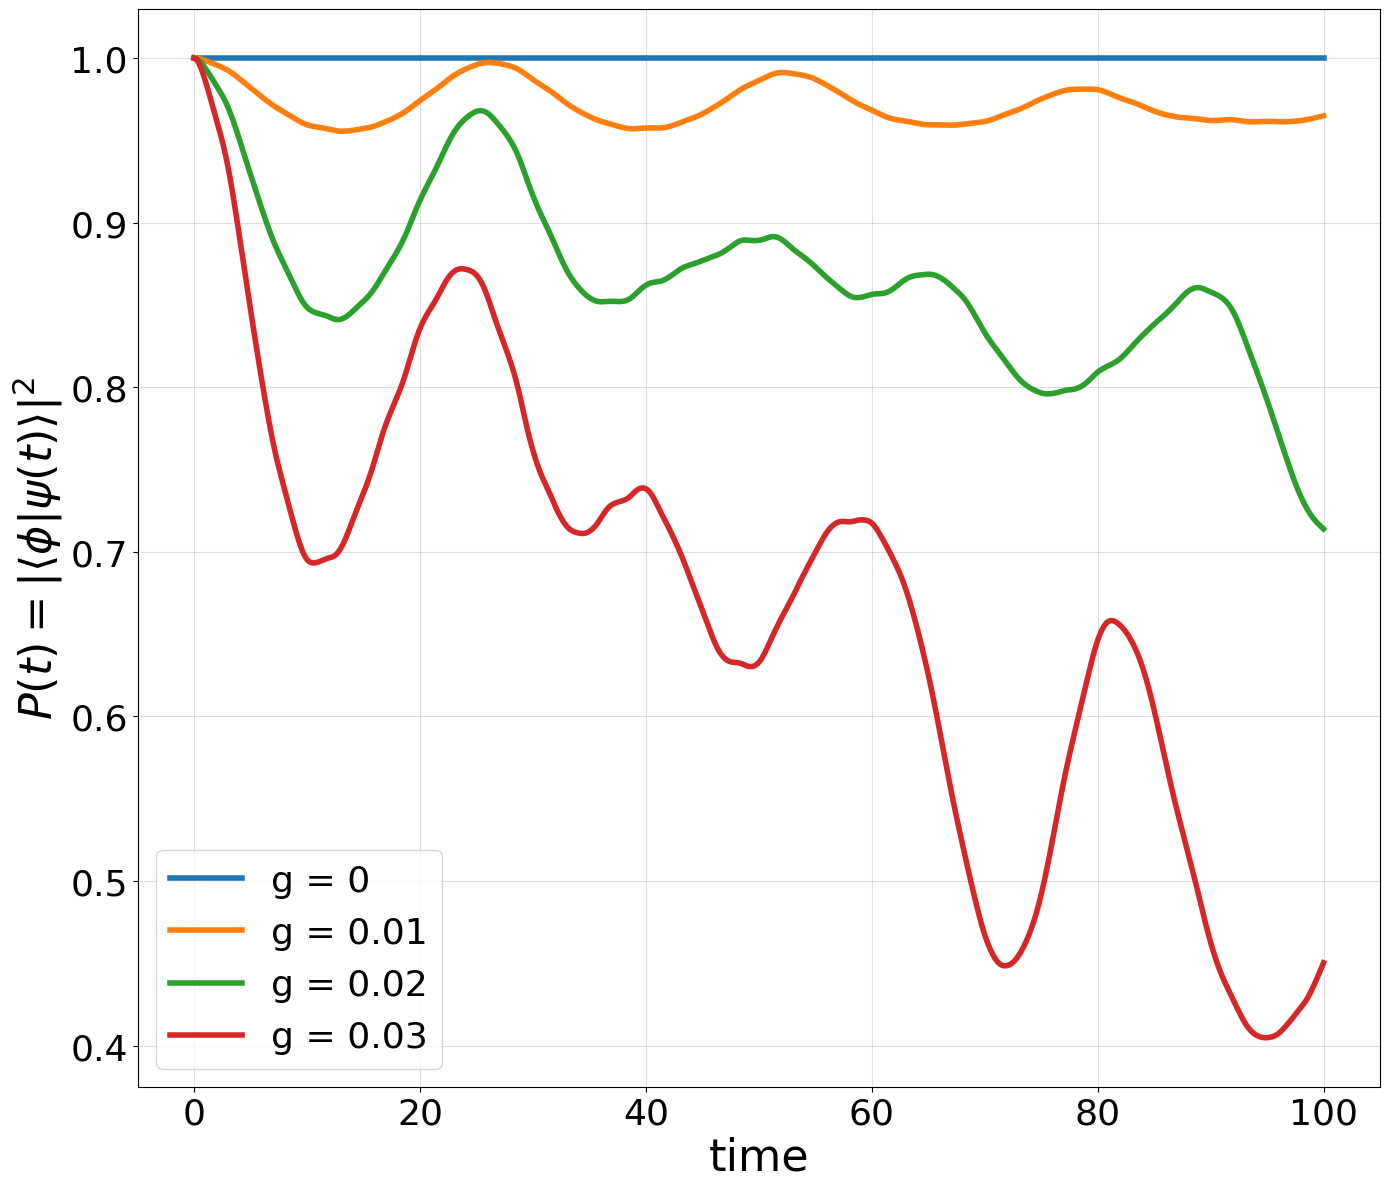

In [ ]:
# parameters
L = 10
N_cav = 2
omega_c = 1.0
omega_e = 1.0
g = 0.03
hbar = 1.0

W = 1
omega_e_list = omega_c + np.linspace(-W/4, W/4, L)
# omega_e_list = (
#     [2 * omega_c] * comb(L, 1)
#     + [2 * omega_c] * (comb(10, 2) - (L - 1) - (L - 2))
#     + [2 * omega_c + U_nnn] * (L - 2)
#     + [2 * omega_c + U_nn] * (L - 1)
# )

# omega_e_list = [omega_e]*L
# coupling_strength = [0.5, 1, 2]
coupling_strength = 1
g_vals = [0, 0.01, 0.02, 0.03]
H, psi0 = 0, 0
t_max = 100
num_t = 500
times = np.linspace(0, t_max, num_t)
P_t_list = []

# # Build H and initial state
# for strength in coupling_strength:

#     H = build_H_cavity_exciton_band(L, N_cav, omega_c, omega_e_list, g, coupling_strength = strength)
#     print(f"H = {H}")
#     psi0 = initial_state(L, N_cav, n_cav_init=2)
#     print(f"psi_0 = {psi0}")

#     P_t, A_t, evals, w = survival_probability(H, psi0, times)
#     P_t_list.append(P_t)

# Build H and initial state
for g in g_vals:
    H = build_H_cavity_exciton_band(L, N_cav, omega_c, omega_e_list, g, coupling_strength = coupling_strength)
    print(f"H = {H}")
    psi0 = initial_state(L, N_cav, n_cav_init=2)
    print(f"psi_0 = {psi0}")

    P_t, A_t, evals, w = survival_probability(H, psi0, times)
    P_t_list.append(P_t)


# ------------------------------------------------------------------
# 5. Plot decay (survival probability)
# ------------------------------------------------------------------

plt.figure(figsize=(14, 12))
for i, P_t in enumerate(P_t_list):
    # plt.plot(times, P_t, lw=4, label=f'strength = {coupling_strength[i]}')
    plt.plot(times, P_t, lw=4, label=f'g = {g_vals[i]}')
from scipy.linalg import logm, sqrtm, expm

plt.xlabel("time", fontsize=32)
plt.ylabel(r"$P(t) = |\langle \phi|\psi(t)\rangle|^2$", fontsize=32)
# plt.title("Survival probability of two-photon initial state", fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=26)
plt.legend(fontsize=26)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# 24.9s

Create only an excitonic model and check thermalization

In [25]:
# parameters
L = 10
# omega_e = 0
hbar = 1.0
keep_sites = [L // 2, L // 2 - 1, L // 2 + 1]
# coupling_strength = 1

# W = 1
# omega_e_list = omega_c + np.linspace(-W/4, W/4, L)
# omega_e_list = [omega_e]*L

H, psi0 = 0, 0
basis = np.arange(2**L)
print(f"basis dim = {len(basis)}")
t_max = 20
num_t = 50
times = np.linspace(0, t_max, num_t)

# Build H and initial state
H = build_H_exciton_band(L, basis = basis)
print(f"H = {H}")
# Build initial state where first two excitons are populated and the cavity is empty
psi0 = initial_state_exciton(L, excited_sites=[L-1, L-2])

non_zero_indices = np.nonzero(psi0)[0]
print(f"Non-zero indices: {non_zero_indices}")

evals, evecs = np.linalg.eigh(H)
proj_psi0 = evecs.T.conj() @ psi0

# --- Thermal state and reduced version ---
beta_star, _ = find_beta_with_neg_temps(H, psi0, bracket=(-100, 100))
weights = np.exp(-beta_star * evals)
weights /= np.sum(weights)
rho_thermal_full = (evecs * weights[np.newaxis, :]) @ evecs.conj().T
red_rho_thermal = reduced_density_matrix_general(rho_thermal_full, basis, keep_sites, L)

# --- Function to compute observables at a single time ---
def compute_observables(t):
    psi_t = evecs @ (np.exp(-1j * evals * t) * proj_psi0)
    rho_t = np.outer(psi_t, psi_t.conj())
    red_rho_t = reduced_density_matrix_general(rho_t, basis, keep_sites, L)

    D = trace_distance_calc(red_rho_t, red_rho_thermal)
    F = fidelity(red_rho_t, red_rho_thermal)
    S = relative_entropy(red_rho_t, red_rho_thermal)
    return D, 1 - F, S

# --- Parallel execution ---
results = Parallel(n_jobs=-1)(delayed(compute_observables)(t) for t in times)

# --- Unpack results ---
trace_distances, infidelities, rel_entropies = map(list, zip(*results))

basis dim = 1024
H = [[ 0.02602751+0.j         -0.00313734+0.03159447j  0.02571533-0.03089134j
  ... -0.02776286-0.01482485j -0.03287922-0.02540411j
  -0.01042249-0.01363419j]
 [-0.00313734-0.03159447j -0.00875185+0.j          0.01350913+0.00753557j
  ...  0.00366369-0.01450241j  0.01500542+0.01641014j
   0.00605438+0.00996932j]
 [ 0.02571533+0.03089134j  0.01350913-0.00753557j  0.01745823+0.j
  ...  0.0083609 +0.01132823j -0.02563108-0.00137954j
  -0.01830709-0.01911799j]
 ...
 [-0.02776286+0.01482485j  0.00366369+0.01450241j  0.0083609 -0.01132823j
  ...  0.01503277+0.j         -0.0172031 -0.01514273j
  -0.04059303+0.02618259j]
 [-0.03287922+0.02540411j  0.01500542-0.01641014j -0.02563108+0.00137954j
  ... -0.0172031 +0.01514273j -0.09820186+0.j
  -0.02251158+0.00488322j]
 [-0.01042249+0.01363419j  0.00605438-0.00996932j -0.01830709+0.01911799j
  ... -0.04059303-0.02618259j -0.02251158-0.00488322j
   0.01748825+0.j        ]]
Non-zero indices: [3]
beta_star = -0.035834664113160775


/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/scipy/linalg/_matfuncs.py:202: LogmNearlySingularWarning: The logm input matrix may be nearly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)


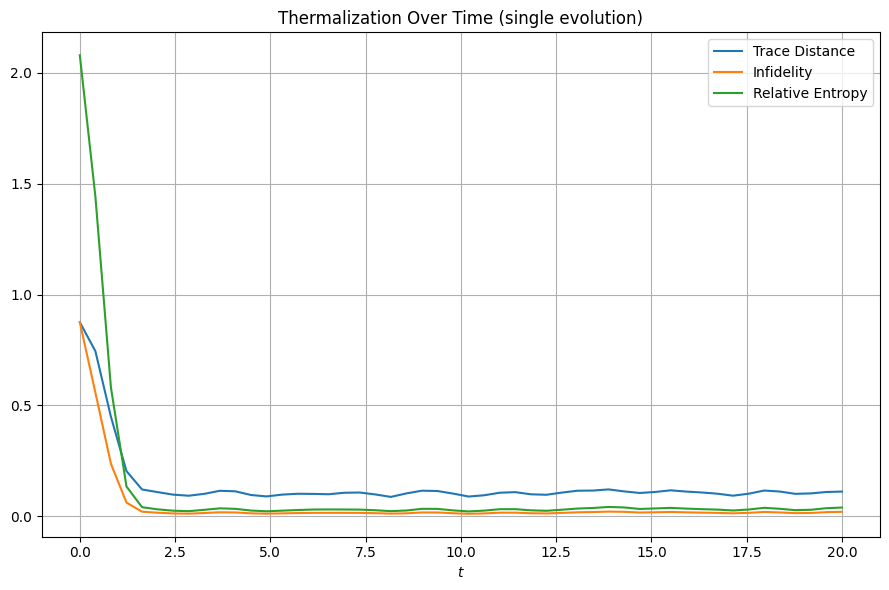

In [26]:
# --- Unpack results ---
trace_distances, infidelities, rel_entropies = map(list, zip(*results))

# --- Plotting ---
plt.figure(figsize=(9, 6))
plt.plot(times, trace_distances, label='Trace Distance')
plt.plot(times, infidelities, label='Infidelity')
plt.plot(times, rel_entropies, label='Relative Entropy')
plt.xlabel(r'$t$')
plt.title('Thermalization Over Time (single evolution)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()